# Forest Carbon Stock Analysis

## Introduction

This notebook analyzes carbon stocks from U.S. forests using data from the USDA Forest Service Research Data Archive (Walters et al. 2024). The dataset covers all U.S. states from 1990 to 2023 and tracks carbon across ecosystem pools (aboveground biomass, soil, litter, etc.)

The goal is to answer the following question: **What are the top 5 states with the highest average annual carbon stock in aboveground biomass from 1990 to 2023, and what region are they in?**

Aboveground biomass was selected as the focus pool because it directly reflects the carbon stored in living trees, and for being a manageable component of forest carbon for climate policy.

## Analysis

### Connect and create a cursor
Connect to the DuckDB database to execute SQL queries and answer the analytical question.

In [1]:
# Import necessary libraries
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Connect to the DuckDB database
conn = duckdb.connect("database/database.duckdb")
cur = conn.cursor()

IOException: IO Error: Cannot open file "C:\Users\hylae\Downloads\MEDS\EDS-213\lab\database-project-213\database\database.duckdb": O arquivo já está sendo usado por outro processo.

File is already open in 
C:\Windows\duckdb.exe (PID 53052)

### Execute SQL query to answer the question:
#### What are the top 5 states with the highest average annual carbon stock in aboveground biomass from 1990 to 2023, and what region are they in?

In [3]:
# Joins stock with state to get the region for each state
# Filters to aboveground biomass only and averages across all years (1990-2023) per state
cur.execute("""
    SELECT state.State_Name,
    state.Region,
    AVG(stock.Value) AS avg_carbon_stock_mmt
FROM stock
JOIN state ON stock.State_ID = state.State_ID
WHERE stock.Pool_ID = 'Aboveground Biomass'
GROUP BY state.State_Name, state.Region
ORDER BY avg_carbon_stock_mmt DESC
LIMIT 5""")
df = cur.df()
df.head()


,State_Name,Region,avg_carbon_stock_mmt
0,California,Pacific Coast,1056.408234
1,Oregon,Pacific Coast,1036.152062
2,Alaska,Pacific Coast,1014.618532
3,Washington,Pacific Coast,871.370297
4,Georgia,South,522.398531


### Visualization


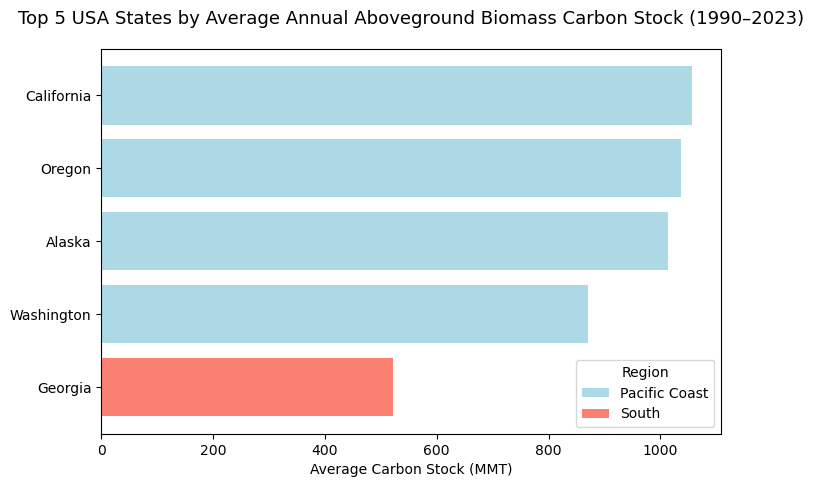

In [8]:

# Define colors per region in a dictionary
region_colors = {
    "Pacific Coast": "lightblue",
    "South": "salmon"
}

# Build the plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    df["State_Name"],
    df["avg_carbon_stock_mmt"],
    color=df["Region"].map(region_colors)
)

# Build legend manually, since color is defined in a dictionary
legend_handles = [
    Patch(facecolor="lightblue", label="Pacific Coast"),
    Patch(facecolor="salmon", label="South")
]
# Invert y-axis so the highest value appears at the top
ax.invert_yaxis()

ax.legend(handles=legend_handles, title="Region")
ax.set_xlabel("Average Carbon Stock (MMT)")
ax.set_title("Top 5 USA States by Average Annual Aboveground Biomass Carbon Stock (1990–2023)", pad=18, size=13)

# Display plot
plt.show()


In [2]:
# Close connection
conn.close()

NameError: name 'conn' is not defined

## Results

The results show that four of the top five states, California, Oregon, Alaska, and Washington, are all in the Pacific Coast region. This is consistent with the dense mature forests and high tree biomass characteristic of the Pacific Northwest and coastal California (Forest Service, 2025). Georgia is the only non-Pacific Coast state in the top five, representing the South region, with approximately 64% of the state being forested (Lambert, Gray, McCollum, Brandeis, & Mark, 2023).

The dominance of Pacific Coast states suggests that conservation and management of these forests is disproportionately important for U.S. carbon storage goals. The disturbances such as wildfires, which are increasing in frequency in California and the Pacific Northwest, could significantly reduce these carbon stocks over time.

## References:

Lambert, S., Gray, J. A., McCollum, J. M., Brandeis, T. J., & Mark. (2023). Georgia’s Forests, 2019. https://doi.org/10.2737/srs-rb-236

Pacific Northwest Region - Mature and Old Growth Forests. (2025, March 25). Retrieved May 15, 2026, from Forest Service website: https://www.fs.usda.gov/r06/planning/mature-and-old-growth-forests
‌
‌